In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

In [2]:
df = pd.read_csv("weather.csv")

print(df.head())
print("\nShape:", df.shape)
print("\nColumns:", df.columns.tolist())

                  date        p     T    Tpot  Tdew    rh  VPmax  VPact  \
0  2020-01-01 00:10:00  1008.89  0.71  273.18 -1.33  86.1   6.43   5.54   
1  2020-01-01 00:20:00  1008.76  0.75  273.22 -1.44  85.2   6.45   5.49   
2  2020-01-01 00:30:00  1008.66  0.73  273.21 -1.48  85.1   6.44   5.48   
3  2020-01-01 00:40:00  1008.64  0.37  272.86 -1.64  86.3   6.27   5.41   
4  2020-01-01 00:50:00  1008.61  0.33  272.82 -1.50  87.4   6.26   5.47   

   VPdef    sh  ...      rho    wv  max. wv     wd  rain  raining  SWDR  PAR  \
0   0.89  3.42  ...  1280.62  1.02     1.60  224.3   0.0      0.0   0.0  0.0   
1   0.95  3.39  ...  1280.33  0.43     0.84  206.8   0.0      0.0   0.0  0.0   
2   0.96  3.39  ...  1280.29  0.61     1.48  197.1   0.0      0.0   0.0  0.0   
3   0.86  3.35  ...  1281.97  1.11     1.48  206.4   0.0      0.0   0.0  0.0   
4   0.79  3.38  ...  1282.08  0.49     1.40  209.6   0.0      0.0   0.0  0.0   

   max. PAR   Tlog  
0       0.0  11.45  
1       0.0  11.51  
2    

In [3]:
# Select features for Isolation Forest
features = ['p', 'T', 'rh', 'wv', 'rain']

X = df[features].copy()

print("Selected Features:")
print(X.head())

print("\nShape:", X.shape)

Selected Features:
         p     T    rh    wv  rain
0  1008.89  0.71  86.1  1.02   0.0
1  1008.76  0.75  85.2  0.43   0.0
2  1008.66  0.73  85.1  0.61   0.0
3  1008.64  0.37  86.3  1.11   0.0
4  1008.61  0.33  87.4  0.49   0.0

Shape: (52696, 5)


In [4]:
# 80% training data and 20% testing data
split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (42156, 5)
Testing shape: (10540, 5)


In [5]:
# Create scaler
scaler = StandardScaler()

# Fit scaler on training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Use the same scaler to transform testing data
X_test_scaled = scaler.transform(X_test)

print("Scaling completed!")

print("\nTraining scaled shape:", X_train_scaled.shape)
print("Testing scaled shape:", X_test_scaled.shape)

Scaling completed!

Training scaled shape: (42156, 5)
Testing scaled shape: (10540, 5)


In [6]:
# Create Isolation Forest model
model = IsolationForest(
    n_estimators=200,
    contamination=0.01,
    random_state=42
)

# Train the model using scaled training data
model.fit(X_train_scaled)

print("Isolation Forest model trained successfully!")

Isolation Forest model trained successfully!


In [7]:
# Predict on test data
predictions = model.predict(X_test_scaled)

# Convert predictions:
#  1  = Normal
# -1  = Anomaly

anomaly_labels = (predictions == -1).astype(int)

print("Prediction completed!\n")

print("Normal (0) and Anomaly (1) count:")
print(pd.Series(anomaly_labels).value_counts())

Prediction completed!

Normal (0) and Anomaly (1) count:
0    10528
1       12
Name: count, dtype: int64


In [8]:
# Calculate anomaly scores
anomaly_scores = model.decision_function(X_test_scaled)

print("Anomaly scores generated!")

# Lower score = more anomalous
print("\nFirst 10 anomaly scores:")
print(anomaly_scores[:10])

Anomaly scores generated!

First 10 anomaly scores:
[0.24184749 0.23896997 0.24095263 0.23806415 0.23870123 0.2405588
 0.23645536 0.23621424 0.23521946 0.2164332 ]


In [9]:
# Create output dataframe from test data
m2_output = df.iloc[split_index:].copy()

# Add ML prediction
m2_output['ml_prediction'] = anomaly_labels

# Add readable status
m2_output['ml_status'] = np.where(
    m2_output['ml_prediction'] == 1,
    'Anomaly',
    'Normal'
)

# Add anomaly score
m2_output['anomaly_score'] = anomaly_scores

# Display important columns
print(
    m2_output[
        ['date', 'p', 'T', 'rh', 'wv', 'rain',
         'ml_prediction', 'ml_status', 'anomaly_score']
    ].head(10)
)

                      date       p     T     rh    wv  rain  ml_prediction  \
42156  2020-10-19 19:30:00  995.43  7.17  78.13  1.43   0.0              0   
42157  2020-10-19 19:40:00  995.36  7.04  78.07  1.03   0.0              0   
42158  2020-10-19 19:50:00  995.28  7.05  77.76  1.08   0.0              0   
42159  2020-10-19 20:00:00  995.38  6.97  78.40  0.92   0.0              0   
42160  2020-10-19 20:10:00  995.41  6.81  78.87  1.10   0.0              0   
42161  2020-10-19 20:20:00  995.67  6.82  78.01  1.35   0.0              0   
42162  2020-10-19 20:30:00  995.80  6.90  77.07  0.81   0.0              0   
42163  2020-10-19 20:40:00  995.64  6.57  79.19  1.00   0.0              0   
42164  2020-10-19 20:50:00  995.62  6.09  81.60  1.05   0.0              0   
42165  2020-10-19 21:00:00  995.68  5.84  83.30  0.37   0.0              0   

      ml_status  anomaly_score  
42156    Normal       0.241847  
42157    Normal       0.238970  
42158    Normal       0.240953  
42159    

In [10]:
# Display only the records detected as anomalies
detected_anomalies = m2_output[
    m2_output['ml_status'] == 'Anomaly'
]

print("Total anomalies detected:", len(detected_anomalies))

display(
    detected_anomalies[
        ['date', 'p', 'T', 'rh', 'wv', 'rain',
         'anomaly_score']
    ]
)

Total anomalies detected: 12


,date,p,T,rh,wv,rain,anomaly_score
46623,2020-11-19 20:00:00,997.47,7.58,89.60,1.61,0.6,-0.007605
51265,2020-12-22 01:40:00,986.55,6.63,97.40,3.33,0.5,-0.016392
51417,2020-12-23 03:00:00,988.93,9.74,100.00,1.16,0.5,-0.004917
51418,2020-12-23 03:10:00,988.82,9.84,100.00,0.80,0.8,-0.041936
51419,2020-12-23 03:20:00,988.65,9.87,100.00,0.91,0.7,-0.037184
51499,2020-12-23 16:40:00,983.19,10.64,100.00,1.89,0.5,-0.002880
52090,2020-12-27 19:10:00,962.45,2.20,54.28,6.81,0.0,-0.000709
52093,2020-12-27 19:40:00,962.17,2.48,48.34,6.65,0.0,-0.005282
52104,2020-12-27 21:30:00,960.90,2.31,46.53,5.83,0.0,-0.000429
52235,2020-12-28 19:20:00,956.35,0.85,100.00,1.95,0.2,-0.017019


In [11]:
# Create standardized M2 output for integration
m2_final = m2_output.rename(columns={
    'date': 'timestamp',
    'T': 'temperature',
    'rh': 'humidity',
    'p': 'pressure',
    'wv': 'wind_speed',
    'rain': 'rainfall'
})

# Keep only required weather data + M2 results
m2_final = m2_final[
    [
        'timestamp',
        'temperature',
        'humidity',
        'pressure',
        'wind_speed',
        'rainfall',
        'ml_prediction',
        'ml_status',
        'anomaly_score'
    ]
]

print(m2_final.head())
print("\nColumns:")
print(m2_final.columns.tolist())

                 timestamp  temperature  humidity  pressure  wind_speed  \
42156  2020-10-19 19:30:00         7.17     78.13    995.43        1.43   
42157  2020-10-19 19:40:00         7.04     78.07    995.36        1.03   
42158  2020-10-19 19:50:00         7.05     77.76    995.28        1.08   
42159  2020-10-19 20:00:00         6.97     78.40    995.38        0.92   
42160  2020-10-19 20:10:00         6.81     78.87    995.41        1.10   

       rainfall  ml_prediction ml_status  anomaly_score  
42156       0.0              0    Normal       0.241847  
42157       0.0              0    Normal       0.238970  
42158       0.0              0    Normal       0.240953  
42159       0.0              0    Normal       0.238064  
42160       0.0              0    Normal       0.238701  

Columns:
['timestamp', 'temperature', 'humidity', 'pressure', 'wind_speed', 'rainfall', 'ml_prediction', 'ml_status', 'anomaly_score']


In [12]:
# Save final M2 output
m2_final.to_csv(
    "m2_anomaly_output.csv",
    index=False
)

print("M2 final output saved successfully!")
print("Shape:", m2_final.shape)

M2 final output saved successfully!
Shape: (10540, 9)


In [13]:
# Final M2 Verification

print("===== M2 ISOLATION FOREST FINAL SUMMARY =====")

print("\nTotal test records:", len(m2_final))
print("Normal records:", (m2_final['ml_status'] == 'Normal').sum())
print("Anomalies detected:", (m2_final['ml_status'] == 'Anomaly').sum())

print("\nOutput columns:")
print(m2_final.columns.tolist())

print("\nDetected Anomalies:")
display(
    m2_final[m2_final['ml_status'] == 'Anomaly'].head()
)

===== M2 ISOLATION FOREST FINAL SUMMARY =====

Total test records: 10540
Normal records: 10528
Anomalies detected: 12

Output columns:
['timestamp', 'temperature', 'humidity', 'pressure', 'wind_speed', 'rainfall', 'ml_prediction', 'ml_status', 'anomaly_score']

Detected Anomalies:


,timestamp,temperature,humidity,pressure,wind_speed,rainfall,ml_prediction,ml_status,anomaly_score
46623,2020-11-19 20:00:00,7.58,89.6,997.47,1.61,0.6,1,Anomaly,-0.007605
51265,2020-12-22 01:40:00,6.63,97.4,986.55,3.33,0.5,1,Anomaly,-0.016392
51417,2020-12-23 03:00:00,9.74,100.0,988.93,1.16,0.5,1,Anomaly,-0.004917
51418,2020-12-23 03:10:00,9.84,100.0,988.82,0.80,0.8,1,Anomaly,-0.041936
51419,2020-12-23 03:20:00,9.87,100.0,988.65,0.91,0.7,1,Anomaly,-0.037184


In [14]:
import matplotlib.pyplot as plt

Normal vs Anomaly Count Bar Chart

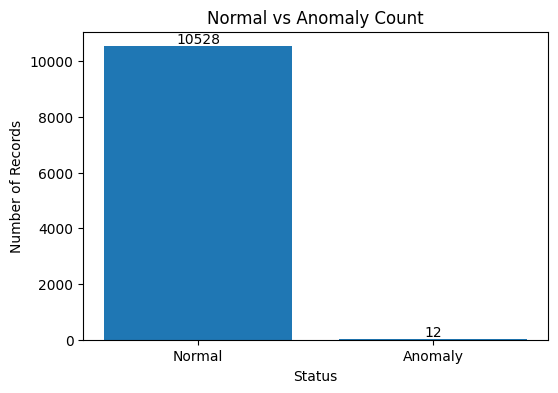

In [15]:
# Count Normal and Anomaly records
counts = m2_final['ml_status'].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(counts.index, counts.values)

plt.title("Normal vs Anomaly Count")
plt.xlabel("Status")
plt.ylabel("Number of Records")

for i, value in enumerate(counts.values):
    plt.text(i, value, str(value), ha='center', va='bottom')

plt.show()

Temperature Time-Series with Anomalies

In [16]:
# Separate anomalies
anomalies = m2_final[
    m2_final['ml_prediction'] == 1
]

plt.figure(figsize=(14, 5))

# Plot all temperature values
plt.plot(
    m2_final['timestamp'],
    m2_final['temperature'],
    label='Temperature'
)

# Highlight anomalies
plt.scatter(
    anomalies['timestamp'],
    anomalies['temperature'],
    label='Detected Anomaly',
    s=50
)

plt.title("Temperature Over Time with Detected Anomalies")
plt.xlabel("Timestamp")
plt.ylabel("Temperature (°C)")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

KeyboardInterrupt: 

Pressure vs Humidity Scatter Plot

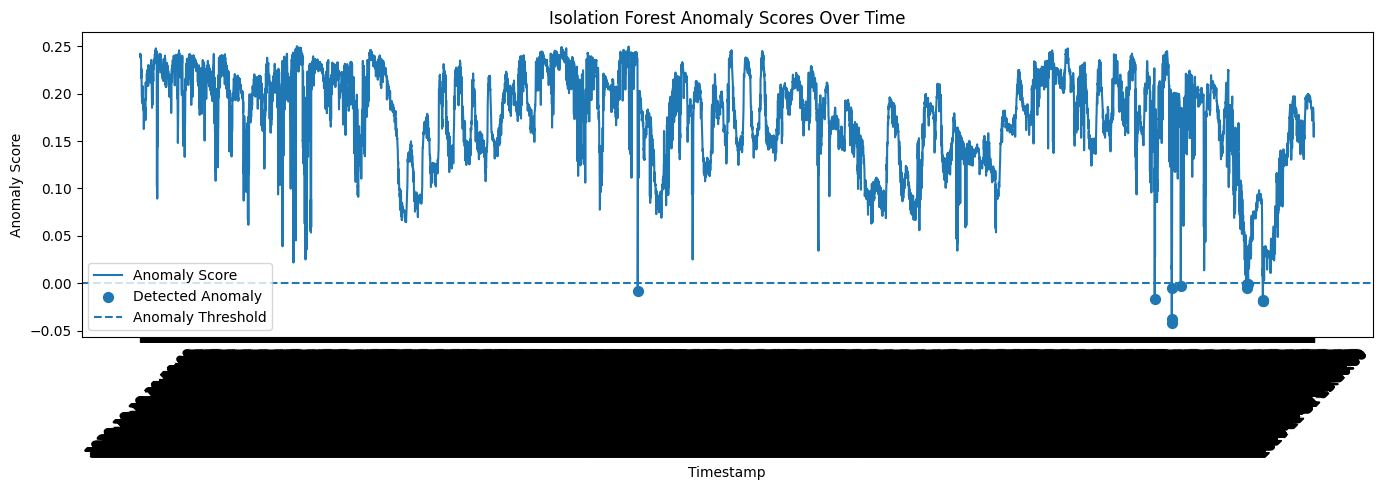

In [ ]:
plt.figure(figsize=(14, 5))

plt.plot(
    m2_final['timestamp'],
    m2_final['anomaly_score'],
    label='Anomaly Score'
)

# Highlight detected anomalies
plt.scatter(
    anomalies['timestamp'],
    anomalies['anomaly_score'],
    label='Detected Anomaly',
    s=50
)

# Reference threshold
plt.axhline(
    y=0,
    linestyle='--',
    label='Anomaly Threshold'
)

plt.title("Isolation Forest Anomaly Scores Over Time")
plt.xlabel("Timestamp")
plt.ylabel("Anomaly Score")

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

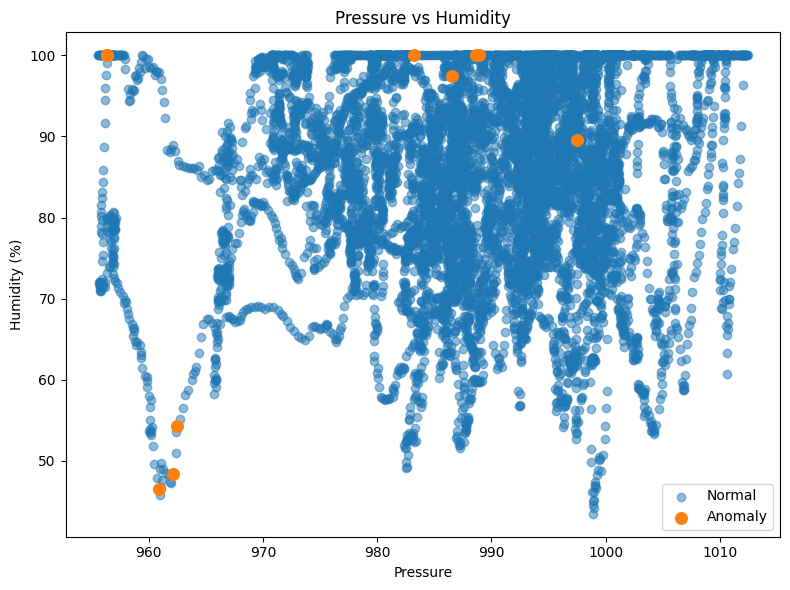

In [ ]:
plt.figure(figsize=(8, 6))

# Normal data
normal = m2_final[
    m2_final['ml_prediction'] == 0
]

plt.scatter(
    normal['pressure'],
    normal['humidity'],
    alpha=0.5,
    label='Normal'
)

# Anomalies
plt.scatter(
    anomalies['pressure'],
    anomalies['humidity'],
    s=70,
    label='Anomaly'
)

plt.title("Pressure vs Humidity")
plt.xlabel("Pressure")
plt.ylabel("Humidity (%)")

plt.legend()
plt.tight_layout()

plt.show()

In [ ]:
import joblib

joblib.dump(model, "isolation_forest.pkl")

['isolation_forest.pkl']

In [18]:
joblib.dump(scaler, "scaler.pkl")

print("Scaler saved successfully!")

Scaler saved successfully!
